## WORKSHOP-1
## Name : SanjayKumar B
## Reg.no : 21224230075

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

(-0.5, 1196.5, 1535.5, -0.5)

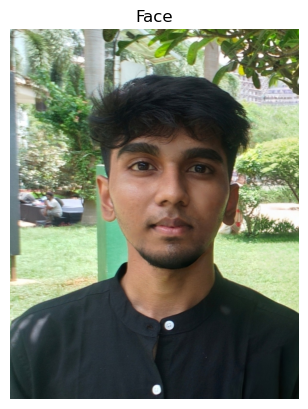

In [2]:
# Load the Face Image
faceImage = cv2.imread("dip.png")
plt.imshow(cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB))
plt.title("Face")
plt.axis("off")

In [3]:
faceImage.shape

(1536, 1197, 3)

In [6]:
#resized_faceImage.shape
faceImage.shape

(1536, 1197, 3)

(-0.5, 730.5, 340.5, -0.5)

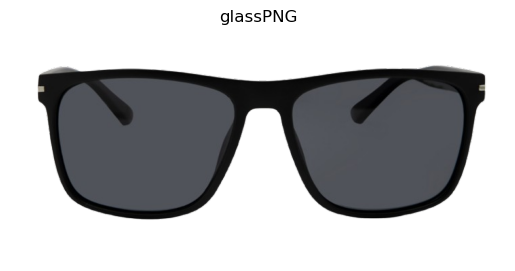

In [7]:
# Load the Sunglass image with Alpha channel
glassPNG = cv2.imread("sunglass.png", cv2.IMREAD_UNCHANGED)
plt.imshow(cv2.cvtColor(glassPNG, cv2.COLOR_BGRA2RGBA))
plt.title("glassPNG")
plt.axis("off")

In [8]:
# Resize the sunglass to fit the face
# Tuned for the uploaded image
glassPNG = cv2.resize(glassPNG, (170, 63), interpolation=cv2.INTER_AREA)
print(glassPNG.shape)

(63, 170, 4)


In [9]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,2]
glassBGR.shape

(63, 170, 3)

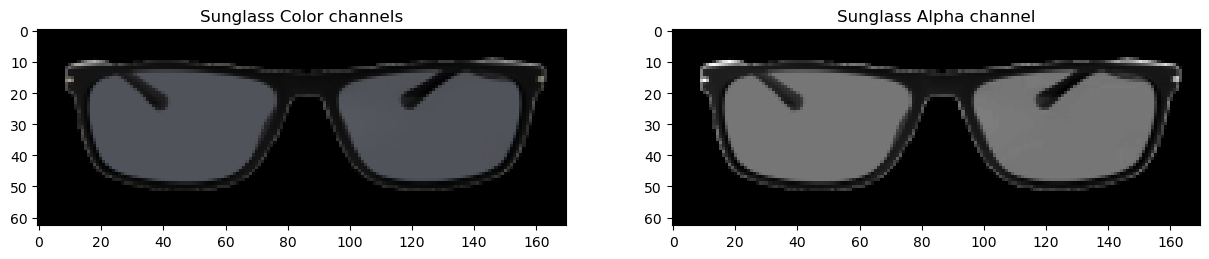

In [10]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

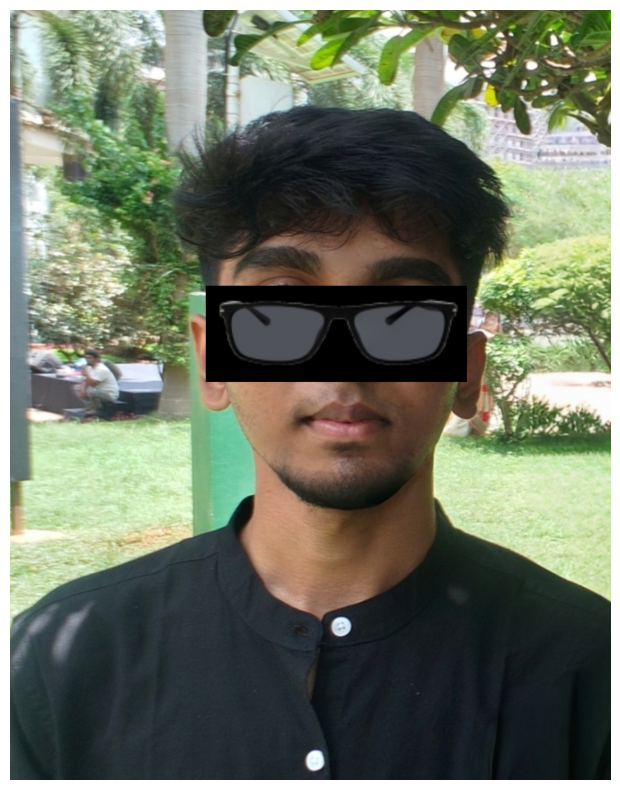

Glasses size: (192, 520, 3)
Position: 390 550


In [22]:
# Make a copy
faceWithGlassesNaive = faceImage.copy()

# Resize sunglasses
glassWidth = 520
glassHeight = int(glassBGR.shape[0] * glassWidth / glassBGR.shape[1])

glassResized = cv2.resize(glassBGR, (glassWidth, glassHeight))

# Position of glasses
x = 390
y = 550

# Place glasses on the eyes
faceWithGlassesNaive[
    y:y + glassHeight,
    x:x + glassWidth
] = glassResized

# Display
plt.figure(figsize=(8, 10))
plt.imshow(faceWithGlassesNaive[..., ::-1])
plt.axis("off")
plt.show()

print("Glasses size:", glassResized.shape)
print("Position:", x, y)

In [17]:
# Make the dimensions of the mask same as the input image.
# Since Face Image is a 3-channel image, we create a 3 channel image for the mask
glassMask = cv2.merge((glassMask1,glassMask1,glassMask1))

# Make the values [0,1] since we are using arithmetic operations
glassMask = np.uint8(glassMask/255)

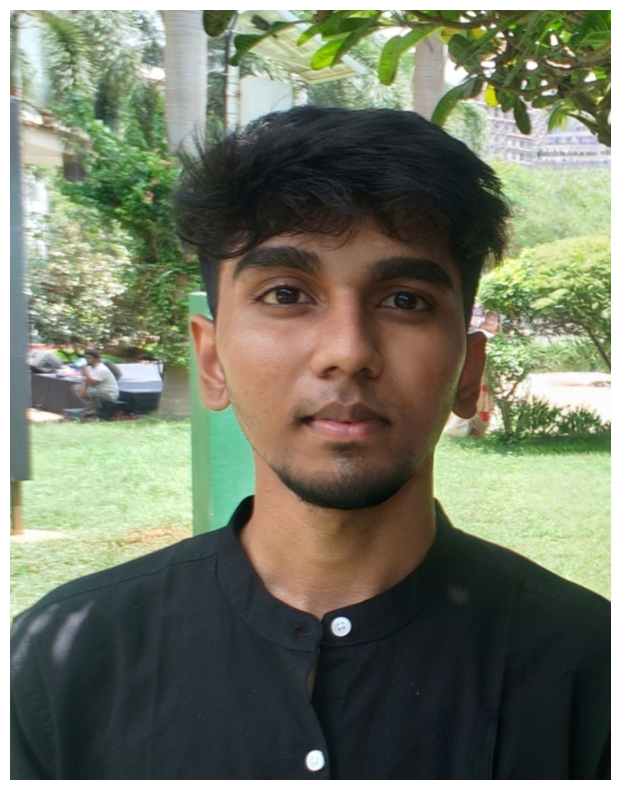

In [23]:
# Make a copy
faceWithGlassesArithmetic = faceImage.copy()

# Eye region - adjust these if needed
x1, y1 = 390, 550
x2, y2 = 870, 720

# Extract eye region
eyeROI = faceWithGlassesArithmetic[y1:y2, x1:x2]

# Resize sunglasses to fit the eyes
glassResized = cv2.resize(
    glassBGR,
    (eyeROI.shape[1], eyeROI.shape[0])
)

# Resize mask to exactly the same size
glassMaskResized = cv2.resize(
    glassMask,
    (eyeROI.shape[1], eyeROI.shape[0])
)

# Make sure mask has 3 channels
if len(glassMaskResized.shape) == 2:
    glassMaskResized = cv2.merge(
        (glassMaskResized, glassMaskResized, glassMaskResized)
    )

# Create masked eye region
maskedEye = cv2.multiply(
    eyeROI.astype(np.float32),
    (1 - glassMaskResized).astype(np.float32)
)

# Create masked glasses
maskedGlass = cv2.multiply(
    glassResized.astype(np.float32),
    glassMaskResized.astype(np.float32)
)

# Combine
eyeROI_final = cv2.add(maskedEye, maskedGlass)

# Convert back to uint8
eyeROI_final = np.uint8(eyeROI_final)

# Put the result back into the face
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeROI_final

# Display
plt.figure(figsize=(8, 10))
plt.imshow(faceWithGlassesArithmetic[..., ::-1])
plt.axis("off")
plt.show()

Mask shape: (63, 170, 3)
Mask minimum: 0.0
Mask maximum: 1.0


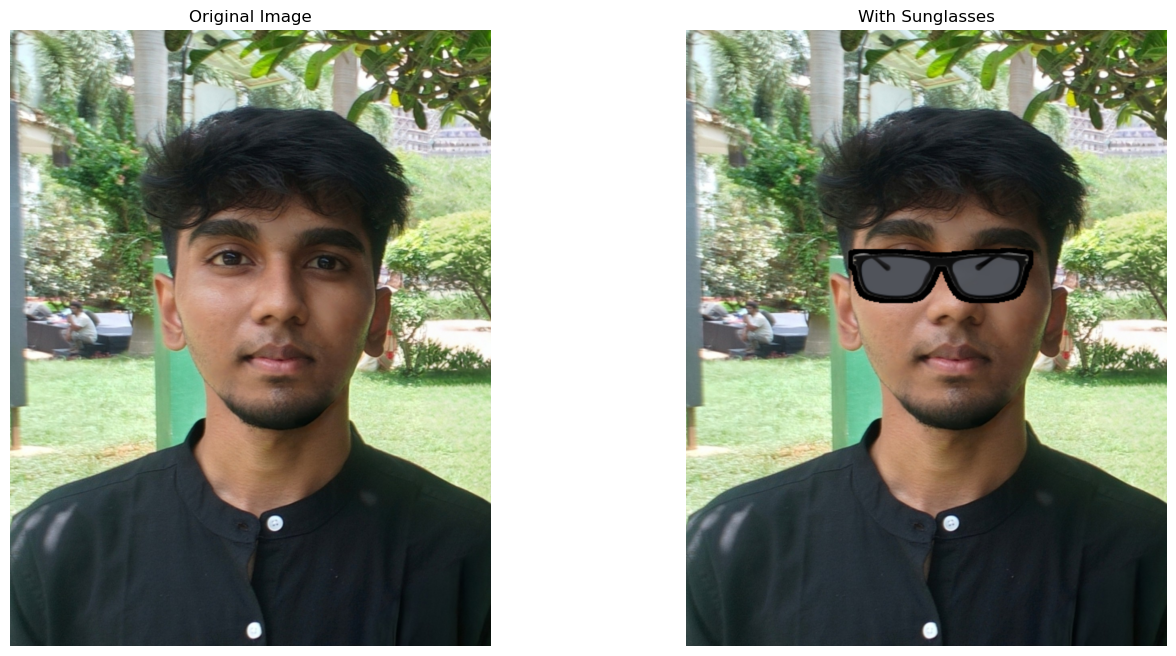

In [29]:
# ============================================
# CREATE A NEW MASK FOR THE SUNGLASSES
# ============================================

# Convert sunglasses to grayscale
glassGray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)

# Create mask from non-black parts
glassMask1 = np.where(glassGray > 10, 255, 0).astype(np.uint8)

# Expand the mask slightly so the black frame is included
kernel = np.ones((5, 5), np.uint8)
glassMask1 = cv2.dilate(glassMask1, kernel, iterations=2)

# Convert mask to 3 channels
glassMask = cv2.merge(
    (glassMask1, glassMask1, glassMask1)
)

# Convert 0-255 to 0-1
glassMask = glassMask.astype(np.float32) / 255.0

print("Mask shape:", glassMask.shape)
print("Mask minimum:", glassMask.min())
print("Mask maximum:", glassMask.max())


# ============================================
# PLACE GLASSES ON EYES
# ============================================

faceWithGlassesArithmetic = faceImage.copy()

# Position
x1, y1 = 390, 530
x2, y2 = 870, 700

# Eye region
eyeROI = faceImage[y1:y2, x1:x2]

# Resize glasses
glassResized = cv2.resize(
    glassBGR,
    (x2 - x1, y2 - y1)
)

# Resize mask
glassMaskResized = cv2.resize(
    glassMask,
    (x2 - x1, y2 - y1)
)

# Blend
eyeROI_float = eyeROI.astype(np.float32)
glass_float = glassResized.astype(np.float32)

maskedEye = eyeROI_float * (1 - glassMaskResized)
maskedGlass = glass_float * glassMaskResized

eyeROIFinal = maskedEye + maskedGlass
eyeROIFinal = np.uint8(np.clip(eyeROIFinal, 0, 255))

# Put back
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeROIFinal


# ============================================
# DISPLAY
# ============================================

plt.figure(figsize=(16, 8))

plt.subplot(121)
plt.imshow(faceImage[..., ::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(faceWithGlassesArithmetic[..., ::-1])
plt.title("With Sunglasses")
plt.axis("off")

plt.show()